In [13]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib import animation
import sunpy
import sunpy.map
import dkist 
import dask.array as da
import h5py
from astropy.time import Time
from astropy.io import ascii, fits
from astropy.wcs import WCS
from astropy.visualization import (ImageNormalize, 
                    SqrtStretch, AsinhStretch)
import astropy.units as u
from ndcube import NDCube

In [2]:
file_Gband_pr = h5py.File("/cluster/scratch/zhuyin/pid_1_123_aux/plot_ready/Gband_AEZDV_pr.hdf5")
Gband_pr_set = file_Gband_pr["vbi_img"]
Gband_pr_da = da.from_array(Gband_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Gband_date_obs = Time(ascii.read("/cluster/scratch/zhuyin/pid_1_123_aux/plot_ready/Gband_AEZDV_date_avg.txt")["DATE-AVG"])

file_Hbeta_pr = h5py.File("/cluster/scratch/zhuyin/pid_1_123_aux/plot_ready/Hbeta_BJOLO_pr.hdf5")
Hbeta_pr_set = file_Hbeta_pr["vbi_img"]
Hbeta_pr_da = da.from_array(Hbeta_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Hbeta_date_obs = Time(ascii.read("/cluster/scratch/zhuyin/pid_1_123_aux/plot_ready/Hbeta_BJOLO_date_avg.txt")["DATE-AVG"])

file_CaIIK_pr = h5py.File("/cluster/scratch/zhuyin/pid_1_123_aux/plot_ready/CaIIK_BZPOW_pr.hdf5")
CaIIK_pr_set = file_CaIIK_pr["vbi_img"]
CaIIK_pr_da = da.from_array(CaIIK_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
CaIIK_date_obs = Time(ascii.read("/cluster/scratch/zhuyin/pid_1_123_aux/plot_ready/CaIIK_BZPOW_date_avg.txt")["DATE-AVG"])

file_TiO_pr = h5py.File("/cluster/scratch/zhuyin/pid_1_123_aux/plot_ready/TiO_BNRPZ_pr.hdf5")
TiO_pr_set = file_TiO_pr["vbi_img"]
TiO_pr_da = da.from_array(TiO_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
TiO_date_obs = Time(ascii.read("/cluster/scratch/zhuyin/pid_1_123_aux/plot_ready/TiO_BNRPZ_date_avg.txt")["DATE-AVG"])

file_Halpha_pr = h5py.File("/cluster/scratch/zhuyin/pid_1_123_aux/plot_ready/Halpha_BLZNL_pr.hdf5")
Halpha_pr_set = file_Halpha_pr["vbi_img"]
Halpha_pr_da = da.from_array(Halpha_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Halpha_date_obs = Time(ascii.read("/cluster/scratch/zhuyin/pid_1_123_aux/plot_ready/Halpha_BLZNL_date_avg.txt")["DATE-AVG"])

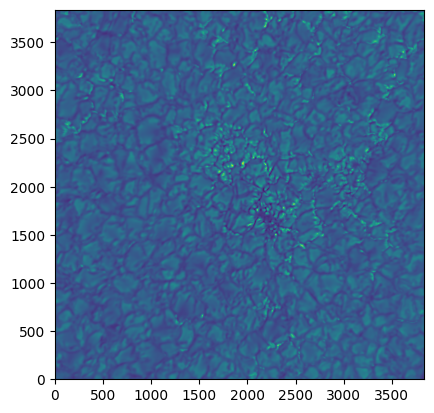

In [4]:
plt.imshow(Gband_pr_da[0,:,:], origin="lower")

In [5]:
file_hri_pr_dset = h5py.File("/cluster/scratch/zhuyin/pid_1_123_aux/plot_ready/HRIEUV_pr.hdf5")
hri_pr_set = file_hri_pr_dset["hrieuv_img"]
hri_pr_da = da.from_array(hri_pr_set, chunks=(1, (4096 - 128*2)//8, (4096 - 128*2)//8))

In [6]:
file_hri_pr_noproj_dset = h5py.File("/cluster/scratch/zhuyin/pid_1_123_aux/plot_ready/HRIEUV_noproj_pr.hdf5")
hri_pr_noproj_array = file_hri_pr_noproj_dset["hrieuv_noproj_img"][:]
hrieuv_no_proj_extent = np.load("/cluster/scratch/zhuyin/pid_1_123_aux/plot_ready/hrieuv_no_proj_extent.npy")
hrieuv_nocrop_noproj_wcs = WCS(fits.getheader("/cluster/scratch/zhuyin/pid_1_123_aux/plot_ready/hri_nocrop_noproj_wcs.fits",
                                        ignore_missing_simple=True))
hrieuv_noproj_wcs = hrieuv_nocrop_noproj_wcs[hrieuv_no_proj_extent[1]:hrieuv_no_proj_extent[3] + 1,
                                   hrieuv_no_proj_extent[0]:hrieuv_no_proj_extent[2] + 1]

In [7]:
hrieuv_date_ear = Time(ascii.read("/cluster/scratch/zhuyin/pid_1_123_aux/plot_ready/HRIEUV_date_ear.txt")["date_ear"])

In [8]:
file_irissji_pr_dset = h5py.File("/cluster/scratch/zhuyin/pid_1_123_aux/plot_ready/IRISSJI_1400_pr.hdf5")
irissji_pr_set = file_irissji_pr_dset["irissji_1400_img"]
irissji_pr_da = da.from_array(irissji_pr_set, chunks=(1, (4096 - 128*2)//8, (4096 - 128*2)//8))
irissji_date_obs = Time(ascii.read("/cluster/scratch/zhuyin/pid_1_123_aux/plot_ready/IRISSJI_1400_date_obs.txt")["date_obs"])

In [9]:
file_aia171_pr_dset = h5py.File("/cluster/scratch/zhuyin/pid_1_123_aux/plot_ready/AIA_171_pr.hdf5")
aia171_pr_set = file_aia171_pr_dset["aia_171_img"]
aia171_pr_da = da.from_array(aia171_pr_set, chunks=(1, (4096 - 128*2)//8, (4096 - 128*2)//8))
aia171_date_obs = Time(ascii.read("/cluster/scratch/zhuyin/pid_1_123_aux/plot_ready/AIA_171_date_obs.txt")["date_obs"])

In [10]:
dkist_vbi_target_header = fits.getheader("/cluster/scratch/zhuyin/pid_1_123_aux/plot_ready/dkist_target_wcs_header_before_crop.fits",
                                        ignore_missing_simple=True)

dkist_vbi_target_data = np.zeros((4096,4096))

dkist_vbi_target_cube = NDCube(dkist_vbi_target_data,WCS(dkist_vbi_target_header, naxis=2))
dkist_vbi_target_cube_crop = dkist_vbi_target_cube[128:-128,128:-128]
dkist_vbi_target_cube_crop_rebin = dkist_vbi_target_cube_crop.rebin((8,8))

Set MJD-BEG to 59876.791095 from DATE-BEG.
Set MJD-AVG to 59876.791095 from DATE-AVG.
Set MJD-END to 59876.791095 from DATE-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [11]:
def plot_vbi_iris_aia(Gband_dset, Gband_date_obs,
                      Hbeta_dset, Hbeta_date_obs,
                      CaIIK_dset, CaIIK_date_obs,
                      TiO_dset, TiO_date_obs,
                      Halpha_dset, Halpha_date_obs,
                      hri_dset, hri_no_proj_dset, hri_date_obs,
                      irissji_dset, irissji_date_obs,
                      aia171_dset, aia171_date_obs,
                      target_wcs, target_wcs_rebin, hri_noproj_wcs,
                      save_dir, figsize=(15,15)):
    
    fig = plt.figure(figsize=figsize, layout="constrained")

    iris_index_ = np.nanargmin(np.abs(hrieuv_date_ear[0] - irissji_date_obs))
    Halpha_index_ = np.nanargmin(np.abs(hrieuv_date_ear[0] - Halpha_date_obs))
    Hbeta_index_ = np.nanargmin(np.abs(hrieuv_date_ear[0] - Hbeta_date_obs))
    CaIIK_index_ = np.nanargmin(np.abs(hrieuv_date_ear[0] - CaIIK_date_obs))
    TiO_index_ = np.nanargmin(np.abs(hrieuv_date_ear[0] - TiO_date_obs))
    Gband_index_ = np.nanargmin(np.abs(hrieuv_date_ear[0] - Gband_date_obs))
    aia171_index_ = np.nanargmin(np.abs(hrieuv_date_ear[0] - aia171_date_obs))

    ax1 = fig.add_subplot(331, projection=hrieuv_noproj_wcs)
    im1 = ax1.imshow(hri_no_proj_dset[0], cmap="sdoaia171",)
    title1 = ax1.set_title(r"EUI/HRI$_{{\rm EUV}}$ 17.4 nm {}".format(hrieuv_date_ear[0].strftime("%Y-%m-%dT%H:%M:%S")))

    ax2 = fig.add_subplot(332, projection=target_wcs_rebin)
    im2 = ax2.imshow(hri_dset[0], cmap="sdoaia171")
    title2 = ax2.set_title(r"Reproj. EUI/HRI$_{{\rm EUV}}$ 17.4 nm {}".format(hrieuv_date_ear[0].strftime("%Y-%m-%dT%H:%M:%S")))

    ax3 = fig.add_subplot(333, projection=target_wcs_rebin)
    im3 = ax3.imshow(aia171_pr_set[aia171_index_], cmap="sdoaia171")
    title3 = ax3.set_title(r"SDO/AIA 171 nm {}".format(aia171_date_obs[aia171_index_].strftime("%Y-%m-%dT%H:%M:%S")))

    ax4 = fig.add_subplot(334, projection=target_wcs)
    im4 = ax4.imshow(Halpha_dset[Halpha_index_], cmap="Greys_r",
               norm=ImageNormalize(vmin=0, vmax=1, stretch=AsinhStretch(0.6)))
    title4 = ax4.set_title(r"DKIST/VBI-R H$\alpha$ {}".format(Halpha_date_obs[Halpha_index_].strftime("%Y-%m-%dT%H:%M:%S")))

    ax5 = fig.add_subplot(335, projection=target_wcs)
    im5 = ax5.imshow(Hbeta_dset[Hbeta_index_], cmap="Greys_r",
               norm=ImageNormalize(vmin=0, vmax=1))
    title5 = ax5.set_title(r"DKIST/VBI-R H$\beta$ {}".format(Hbeta_date_obs[Hbeta_index_].strftime("%Y-%m-%dT%H:%M:%S")))
        
    ax6 = fig.add_subplot(336, projection=target_wcs_rebin)
    im6 = ax6.imshow(irissji_dset[iris_index_], cmap="irissji1400")
    title6 = ax6.set_title(r"IRIS/SJI 140.0 nm {}".format(irissji_date_obs[iris_index_].strftime("%Y-%m-%dT%H:%M:%S")))

    ax7 = fig.add_subplot(337, projection=target_wcs)
    im7 = ax7.imshow(Gband_dset[Gband_index_], cmap="Greys_r",
               norm=ImageNormalize(vmin=0, vmax=1))
    title7 = ax7.set_title(r"DKIST/VBI-B G-band {}".format(Gband_date_obs[Gband_index_].strftime("%Y-%m-%dT%H:%M:%S")))

    ax8 = fig.add_subplot(338, projection=target_wcs)
    im8 = ax8.imshow(CaIIK_dset[CaIIK_index_], cmap="Greys_r",
               norm=ImageNormalize(vmin=0, vmax=1))
    title8 = ax8.set_title(r"DKIST/VBI-B Ca II K {}".format(CaIIK_date_obs[CaIIK_index_].strftime("%Y-%m-%dT%H:%M:%S")))

    ax9 = fig.add_subplot(339, projection=target_wcs)
    im9 = ax9.imshow(TiO_dset[TiO_index_], cmap="Greys_r",
               norm=ImageNormalize(vmin=0, vmax=1))
    title9 = ax9.set_title(r"DKIST/VBI-R TiO {}".format(TiO_date_obs[TiO_index_].strftime("%Y-%m-%dT%H:%M:%S")))

    for ax_ in (ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9):
        ax_.coords.grid(True, color='white', ls=':', lw=0.8, alpha=0.8)

    ax1.coords[0].set_ticks(spacing=30. * u.arcsec)
    ax1.coords[1].set_ticks(spacing=30. * u.arcsec)
    
    for ax_ in (ax1, ax2, ax3, ax4, ax5, ax6, ax8, ax9):
        ax_.coords[0].axislabels.set_visible(False)
        ax_.coords[1].axislabels.set_visible(False)
    
    ax7.coords[0].set_axislabel("Helioprojective Longitude (Solar-X)")
    ax7.coords[1].set_axislabel("Helioprojective Latitude (Solar-Y)")

    def update_fig(ii, fig, ims, axes, titles,
                   Gband_dset, Gband_date_obs,
                   Hbeta_dset, Hbeta_date_obs,
                   CaIIK_dset, CaIIK_date_obs,
                   TiO_dset, TiO_date_obs,
                   Halpha_dset, Halpha_date_obs,
                   hri_dset, hri_pr_noproj_array, hrieuv_date_ear,
                   irissji_dset, irissji_date_obs,
                   aia171_dset, aia171_date_obs,):
        
        iris_index_ = np.nanargmin(np.abs(hrieuv_date_ear[ii] - irissji_date_obs))
        Halpha_index_ = np.nanargmin(np.abs(hrieuv_date_ear[ii] - Halpha_date_obs))
        Hbeta_index_ = np.nanargmin(np.abs(hrieuv_date_ear[ii] - Hbeta_date_obs))
        CaIIK_index_ = np.nanargmin(np.abs(hrieuv_date_ear[ii] - CaIIK_date_obs))
        TiO_index_ = np.nanargmin(np.abs(hrieuv_date_ear[ii] - TiO_date_obs))
        Gband_index_ = np.nanargmin(np.abs(hrieuv_date_ear[ii] - Gband_date_obs))
        aia171_index_ = np.nanargmin(np.abs(hrieuv_date_ear[ii] - aia171_date_obs))
        
        ims[0].set_data(hri_pr_noproj_array[ii])
        ims[1].set_data(hri_dset[ii])
        ims[2].set_data(aia171_dset[aia171_index_])
        ims[3].set_data(Halpha_dset[Halpha_index_])
        ims[4].set_data(Hbeta_dset[Hbeta_index_])
        ims[5].set_data(irissji_dset[iris_index_])
        ims[6].set_data(Gband_dset[Gband_index_])
        ims[7].set_data(CaIIK_dset[CaIIK_index_])
        ims[8].set_data(TiO_dset[TiO_index_])

        titles[0].set_text(r"EUI/HRI$_{{\rm EUV}}$ 17.4 nm {}".format(hrieuv_date_ear[ii].strftime("%Y-%m-%dT%H:%M:%S")))
        titles[1].set_text(r"Reproj. EUI/HRI$_{{\rm EUV}}$ 17.4 nm {}".format(hrieuv_date_ear[ii].strftime("%Y-%m-%dT%H:%M:%S")))
        titles[2].set_text(r"SDO/AIA 171 nm {}".format(aia171_date_obs[aia171_index_].strftime("%Y-%m-%dT%H:%M:%S")))
        titles[3].set_text(r"DKIST/VBI-R H$\alpha$ {}".format(Halpha_date_obs[Halpha_index_].strftime("%Y-%m-%dT%H:%M:%S")))
        titles[4].set_text(r"DKIST/VBI-R H$\beta$ {}".format(Hbeta_date_obs[Hbeta_index_].strftime("%Y-%m-%dT%H:%M:%S")))
        titles[5].set_text(r"IRIS/SJI 140.0 nm {}".format(irissji_date_obs[iris_index_].strftime("%Y-%m-%dT%H:%M:%S")))
        titles[6].set_text(r"DKIST/VBI-R Gband {}".format(Gband_date_obs[Gband_index_].strftime("%Y-%m-%dT%H:%M:%S")))
        titles[7].set_text(r"DKIST/VBI-R CaIIK {}".format(CaIIK_date_obs[CaIIK_index_].strftime("%Y-%m-%dT%H:%M:%S")))
        titles[8].set_text(r"DKIST/VBI-R TiO {}".format(TiO_date_obs[TiO_index_].strftime("%Y-%m-%dT%H:%M:%S")))
    
    anim = animation.FuncAnimation(fig, update_fig, frames=range(1,5),          #tqdm(range(1,len(hrieuv_date_ear))) 
                                   fargs=(fig, (im1, im2, im3, im4, im5, im6, im7, im8, im9),
                                          (ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9),
                                          (title1, title2, title3, title4, title5, title6, title7, title8, title9),
                                          Gband_pr_da, Gband_date_obs,
                                          Hbeta_pr_da, Hbeta_date_obs,
                                          CaIIK_pr_da, CaIIK_date_obs,
                                          TiO_pr_da, TiO_date_obs,
                                          Halpha_pr_da, Halpha_date_obs,
                                          hri_pr_da, hri_pr_noproj_array, hrieuv_date_ear,
                                          irissji_pr_da, irissji_date_obs,
                                          aia171_pr_da, aia171_date_obs,),
                                          blit=False)
    
    anim.save(save_dir, fps=30, dpi=300)


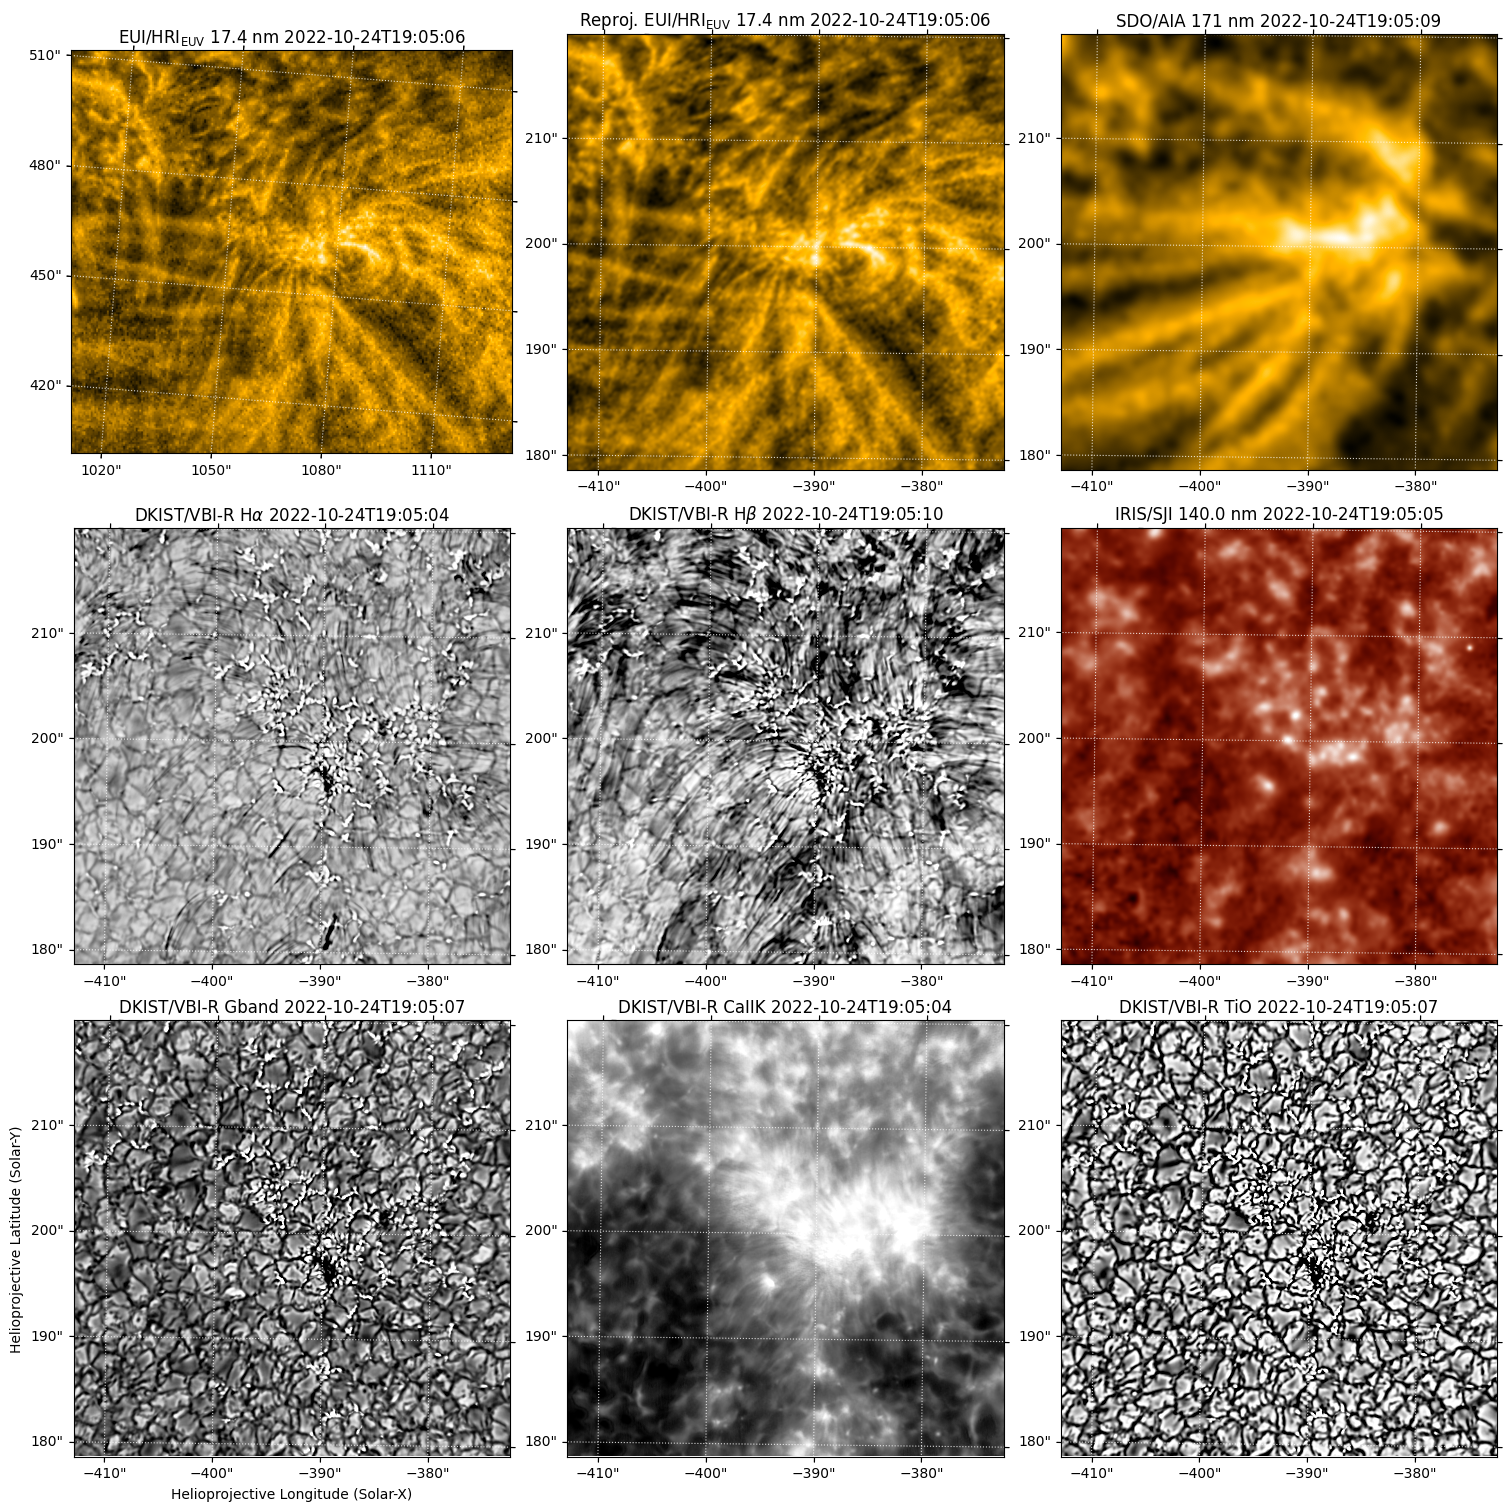

In [14]:
plot_vbi_iris_aia(Gband_pr_da, Gband_date_obs,
                  Hbeta_pr_da, Hbeta_date_obs,
                  CaIIK_pr_da, CaIIK_date_obs,
                  TiO_pr_da, TiO_date_obs,
                  Halpha_pr_da, Halpha_date_obs,
                  hri_pr_da, hri_pr_noproj_array, hrieuv_date_ear,
                  irissji_pr_da, irissji_date_obs,
                  aia171_pr_da, aia171_date_obs,
                  dkist_vbi_target_cube_crop.wcs, dkist_vbi_target_cube_crop_rebin.wcs,
                  hrieuv_noproj_wcs,
                  save_dir="/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/figs/movie/movie_vbi_iris_aia.mp4",
                  figsize=(15,15))